# 1. import

In [15]:
# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 관련 라이브러리
from sklearn.datasets import load_breast_cancer # 예제 데이터
from sklearn.model_selection import train_test_split # 데이터 분할
from sklearn.preprocessing import StandardScaler # 데이터 정규화 라이브러리
from sklearn.linear_model import LogisticRegression # 모델
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)

# 2. 데이터 로드

In [8]:
# 유방암 데이터셋 로드(이진 분류 문제)
data = load_breast_cancer()

# 입력 변수(feature)
X = data.data

## 정답 (target)
y = data.target

y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

# 3. 데이터 분할

In [10]:
# 데이터를 학습용/테스트용으로 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20%를 테스트로 사용
    random_state=42, # 결과 재현 기능 (크게 신경 안써도 된다)
)

# 4. 데이터 전처리 (정규화)

In [13]:
# 스탠다드 스케일러 라이브러리(StandardScaler)를 사용해서 정규화 처리
# 정규화 하면 평균이 0이 되고, 표준 편차가 1이 될 것이다.
scaler = StandardScaler() # 스케일러 변수에 정규화 처리

# 학습 데이터로 scaler 학습 후 변환
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_test

array([[-0.46649743, -0.13728933, -0.44421138, ..., -0.19435087,
         0.17275669,  0.20372995],
       [ 1.36536344,  0.49866473,  1.30551088, ...,  0.99177862,
        -0.561211  , -1.00838949],
       [ 0.38006578,  0.06921974,  0.40410139, ...,  0.57035018,
        -0.10783139, -0.20629287],
       ...,
       [-0.73547237, -0.99852603, -0.74138839, ..., -0.27741059,
        -0.3820785 , -0.32408328],
       [ 0.02898271,  2.0334026 ,  0.0274851 , ..., -0.49027026,
        -1.60905688, -0.33137507],
       [ 1.87216885,  2.80077153,  1.80354992, ...,  0.7925579 ,
        -0.05868885, -0.09467243]], shape=(114, 30))

# 5. 모델 생성 및 학습

In [16]:
# Logistic Regression 모델 생성
model = LogisticRegression()

# 모델 학습
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 6. 예측 수행

In [20]:
# 클래스 예측 (0 또는 1)
y_pred = model.predict(X_test)

# 확률 예측
y_prod = model.predict_proba(X_test)[:, 1]

In [22]:
y_prod

array([8.86409750e-01, 9.00936206e-06, 3.07909541e-03, 9.99489866e-01,
       9.99939361e-01, 9.48087773e-11, 1.53672648e-09, 3.49030633e-02,
       6.20657860e-01, 9.99240597e-01, 9.50128217e-01, 1.24071210e-02,
       9.93926181e-01, 1.43930883e-01, 9.98378244e-01, 7.40182295e-04,
       9.98147541e-01, 9.99988834e-01, 9.99999182e-01, 1.11701472e-06,
       9.15836610e-01, 9.90252217e-01, 4.33732393e-09, 9.99921081e-01,
       9.98861257e-01, 9.99415413e-01, 9.98925555e-01, 9.94024817e-01,
       9.97146883e-01, 8.18296669e-06, 9.99482590e-01, 9.99851240e-01,
       9.97839056e-01, 9.94505862e-01, 9.99859294e-01, 9.97576657e-01,
       5.75840151e-02, 9.97101296e-01, 8.87859084e-05, 9.51863624e-01,
       9.99928757e-01, 4.06608387e-04, 9.97533594e-01, 9.99036115e-01,
       9.80010795e-01, 9.28445266e-01, 9.99601428e-01, 9.99509374e-01,
       9.69530199e-01, 9.99385984e-01, 1.20346382e-04, 5.31315374e-08,
       6.91788480e-01, 9.86770623e-01, 9.99972637e-01, 9.90454756e-01,
      

# 7. 모델 성능 평가

In [26]:
# Accuracy 계산
acc = accuracy_score(y_test, y_pred)

# Precision 계산
precision = precision_score(y_test, y_pred)

# Recall 계산
recall = recall_score(y_test, y_pred)

# F1-Score 계산
f1 = f1_score(y_test, y_pred)

# 결과 출력
print(f"========== 모델 성능 ==========")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

========== 모델 성능 ==========
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Score: 0.9790


# 8. Confusion Matrix 시각화

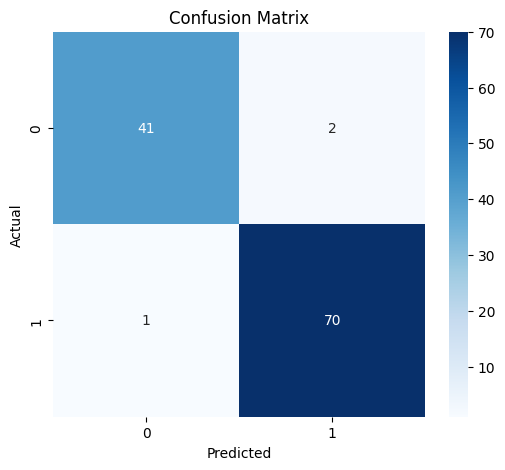

In [28]:
# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Headmap으로 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# 제목 및 라벨
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 8-2. ROC Curve 시각화

In [ ]:
# FPR, TPR 계산
fpr, tpr, thresholds = roc_curve(y_test, y_prod) # 확률 값(y_prod)으로 뽑았다.

# AUC 계산
roc_auc = auc(fpr, tpr)

# 그래프 그리기
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}") 

# 기준선
plt.plot([0,1], [0,1], linestyle='--')

